In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Dataset**

In [ ]:
df=pd.read_csv("cardekho_dataset.csv")
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [ ]:
print(df.columns)

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB
None


In [ ]:
print(df.isnull().sum())

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64


In [ ]:
df.shape

(15411, 14)

# Insights about dataset

---



**Total Brands**: **32**


**Kms Driven**:

Range from 100kms to 38,00,000kms

**Vehicle Age**:

Range from 1 year old to 29 year old

**Selling Price**:

From 40 thousand to 3 crore 95 lakh


**Seller Type:**

1.Individual

2.Dealer

3.Trustmark Dealer


**Fuel Type**:

1.Petrol

2.Diesel

3.CNG

4.Electric

**Transmission Type**:

1.Manual

2.Automatic

**Mileage**:

From 4kmpl to 34kmpl

<Axes: xlabel='vehicle_age', ylabel='Count'>

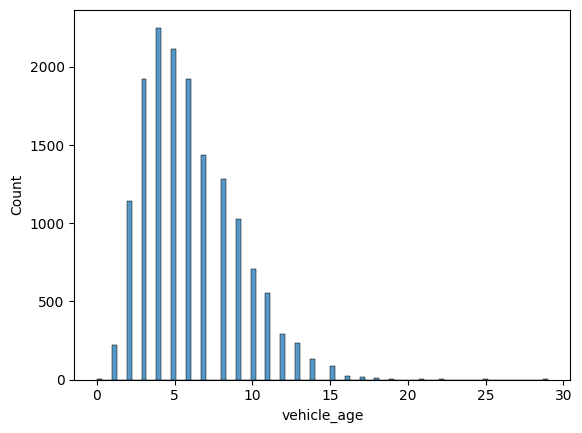

In [ ]:
sns.histplot(data=df,x='vehicle_age')


Not likely anyone would be willing to buy a car older than 15 years due to the current emission norms.

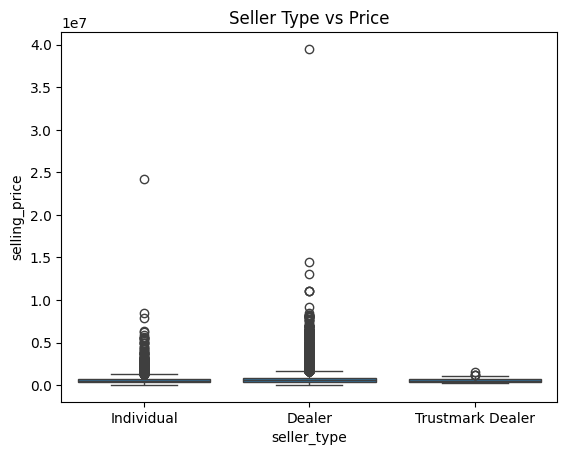

In [ ]:
sns.boxplot(x="seller_type",y="selling_price",data=df)
plt.title("Seller Type vs Price")
plt.show()

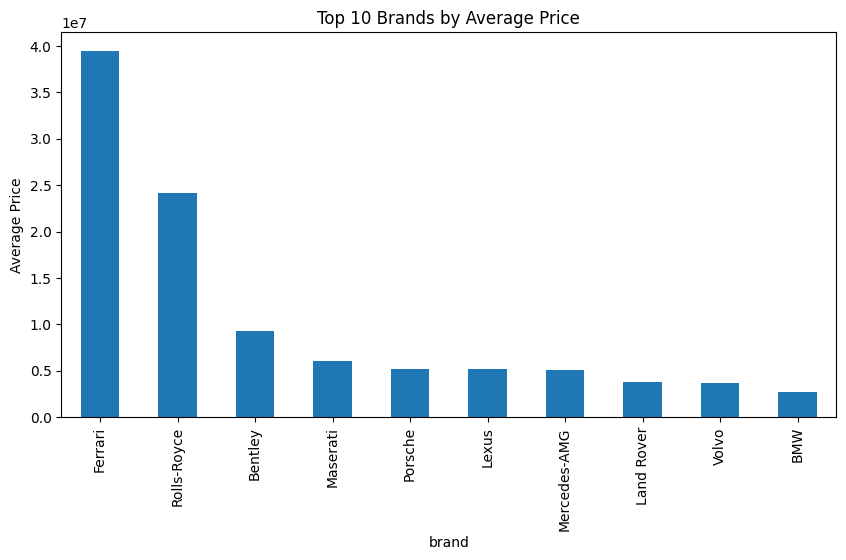

In [ ]:
brand_price=df.groupby("brand")["selling_price"].mean().sort_values(ascending=False).head(10)
brand_price.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Brands by Average Price")
plt.ylabel("Average Price")
plt.show()

# **PreProcessing**

In [ ]:
df=df.drop(["Unnamed: 0", "car_name", "model"], axis=1)

In [ ]:
df=pd.get_dummies(df)

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df[(df["mileage"]>30)].head()


,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,brand_Audi,brand_BMW,brand_Bentley,brand_Datsun,brand_Ferrari,brand_Force,brand_Ford,brand_Honda,brand_Hyundai,brand_ISUZU,brand_Isuzu,brand_Jaguar,brand_Jeep,brand_Kia,brand_Land Rover,brand_Lexus,brand_MG,brand_Mahindra,brand_Maruti,brand_Maserati,brand_Mercedes-AMG,brand_Mercedes-Benz,brand_Mini,brand_Nissan,brand_Porsche,brand_Renault,brand_Rolls-Royce,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual
169,3,52000,33.54,998,67.04,5,435000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True
182,8,64000,33.54,998,67.04,5,270000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True
317,3,28000,31.79,998,58.33,5,455000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True
422,5,45000,30.46,796,47.30,5,350000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True
480,5,42000,33.44,796,40.30,4,260000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True


Vehicles with over 30 mileage are of CNG fuel type. This is understandable.


In [ ]:
df[df["seats"]==0]


,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,brand_Audi,brand_BMW,brand_Bentley,brand_Datsun,brand_Ferrari,brand_Force,brand_Ford,brand_Honda,brand_Hyundai,brand_ISUZU,brand_Isuzu,brand_Jaguar,brand_Jeep,brand_Kia,brand_Land Rover,brand_Lexus,brand_MG,brand_Mahindra,brand_Maruti,brand_Maserati,brand_Mercedes-AMG,brand_Mercedes-Benz,brand_Mini,brand_Nissan,brand_Porsche,brand_Renault,brand_Rolls-Royce,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual
3217,18,40000,13.00,1493,100.00,0,115000,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True
12619,2,10000,19.39,1461,108.49,0,1154000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True


Invalid Entry as a car can't have 0 seats

In [ ]:
df=df[df["seats"]>0]

In [ ]:
df[df["seats"]==0]

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,brand_Audi,brand_BMW,brand_Bentley,brand_Datsun,brand_Ferrari,brand_Force,brand_Ford,brand_Honda,brand_Hyundai,brand_ISUZU,brand_Isuzu,brand_Jaguar,brand_Jeep,brand_Kia,brand_Land Rover,brand_Lexus,brand_MG,brand_Mahindra,brand_Maruti,brand_Maserati,brand_Mercedes-AMG,brand_Mercedes-Benz,brand_Mini,brand_Nissan,brand_Porsche,brand_Renault,brand_Rolls-Royce,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual


Converting the Price into lakhs for better undersatnding

In [ ]:
#df.loc[:, "selling_price_in_lakhs"] = df["selling_price"] / 100000
#df.head()


Invalid Entry for Vehicle Age

In [ ]:
df[df["vehicle_age"]==0]


,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,brand_Audi,brand_BMW,brand_Bentley,brand_Datsun,brand_Ferrari,brand_Force,brand_Ford,brand_Honda,brand_Hyundai,brand_ISUZU,brand_Isuzu,brand_Jaguar,brand_Jeep,brand_Kia,brand_Land Rover,brand_Lexus,brand_MG,brand_Mahindra,brand_Maruti,brand_Maserati,brand_Mercedes-AMG,brand_Mercedes-Benz,brand_Mini,brand_Nissan,brand_Porsche,brand_Renault,brand_Rolls-Royce,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual
5078,0,5000,20.89,1197,81.80,5,550000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True
7789,0,30000,18.15,1198,82.00,6,400000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True
10315,0,2000,22.48,1995,187.74,5,4850000,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False
11486,0,2000,22.48,1995,187.74,5,4850000,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False
12157,0,5000,21.70,998,67.00,5,500000,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True


In [ ]:
df["vehicle_age"]=df["vehicle_age"].replace(0,1)


In [ ]:
df[df["vehicle_age"]==0]

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,brand_Audi,brand_BMW,brand_Bentley,brand_Datsun,brand_Ferrari,brand_Force,brand_Ford,brand_Honda,brand_Hyundai,brand_ISUZU,brand_Isuzu,brand_Jaguar,brand_Jeep,brand_Kia,brand_Land Rover,brand_Lexus,brand_MG,brand_Mahindra,brand_Maruti,brand_Maserati,brand_Mercedes-AMG,brand_Mercedes-Benz,brand_Mini,brand_Nissan,brand_Porsche,brand_Renault,brand_Rolls-Royce,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual


# **Model Training**

In [ ]:
X=df.drop("selling_price", axis=1)
y=df["selling_price"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

**Model** **1**

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train,y_train)

y_pred_lr=lr.predict(X_test)

**Model 2**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()
rf.fit(X_train,y_train)

y_pred_rf=rf.predict(X_test)

**Model 3**

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

**Computing R2 values**

In [ ]:
from sklearn.metrics import r2_score
r2_lr=r2_score(y_test,y_pred_lr)
r2_rf=r2_score(y_test,y_pred_rf)
r2_dt=r2_score(y_test,y_pred_dt)
print("Linear Regression R2:",r2_lr)
print("Random Forest R2:",r2_rf)
print("Decision Tree R2:",r2_dt)

Linear Regression R2: 0.7362567294281653
Random Forest R2: 0.9447737846236982
Decision Tree R2: 0.9046208983282242


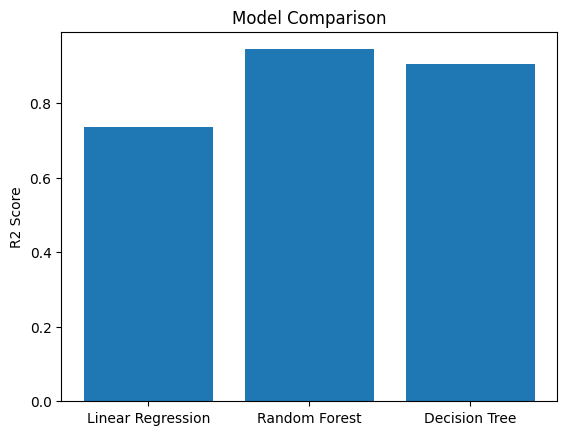

In [ ]:
models=["Linear Regression", "Random Forest","Decision Tree"]
scores=[r2_lr, r2_rf,r2_dt]

plt.bar(models,scores)
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()

# **Visualizations**

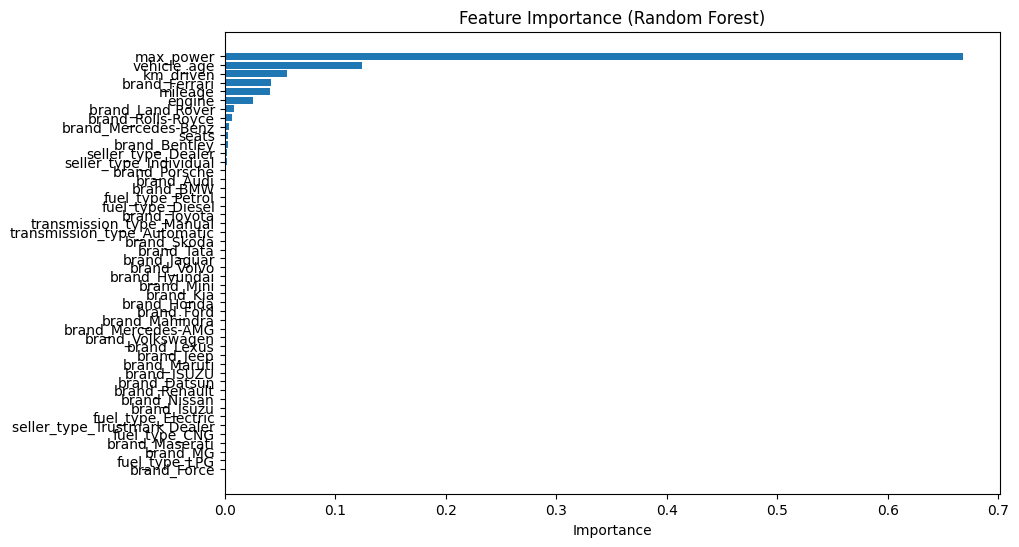

In [ ]:
importances=rf.feature_importances_
features=X.columns

feat_df=pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

In [ ]:
#Remove dummy columns
feat_df_clean = feat_df[
    ~feat_df["Feature"].str.contains("brand_")
]

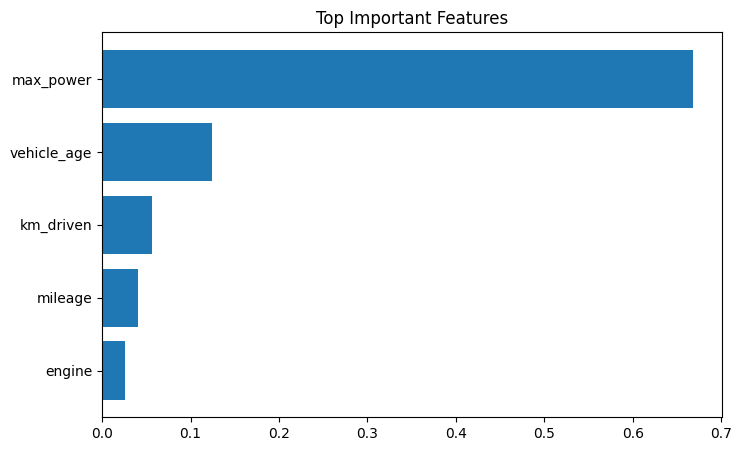

In [ ]:
feat_df_clean = feat_df_clean.head()
plt.figure(figsize=(8,5))
plt.barh(feat_df_clean["Feature"], feat_df_clean["Importance"])
plt.gca().invert_yaxis()
plt.title("Top Important Features")
plt.show()

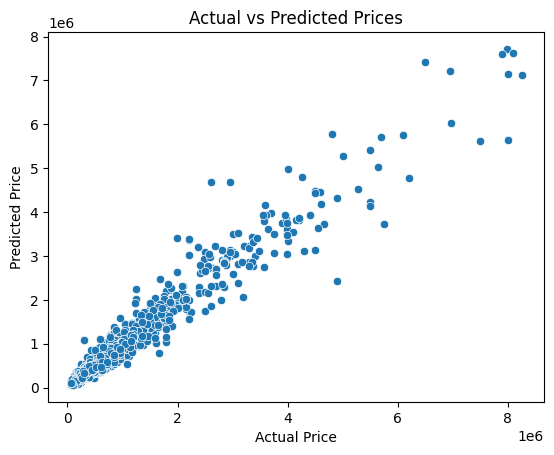

In [ ]:
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

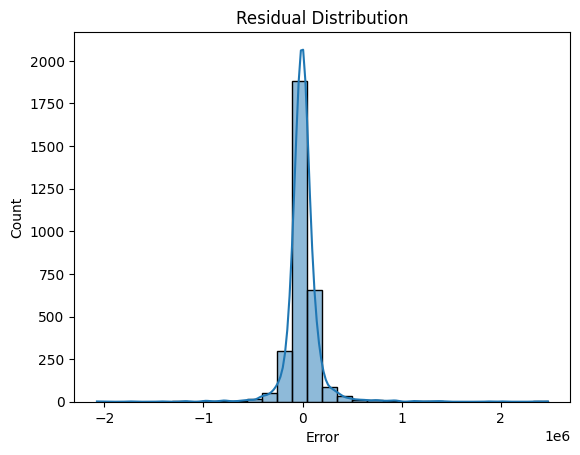

In [ ]:
residuals = y_test - y_pred_rf

sns.histplot(residuals, bins=30, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.show()

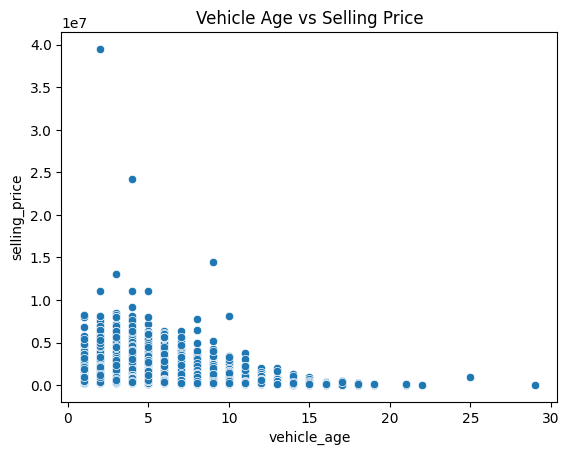

In [ ]:
sns.scatterplot(x=df["vehicle_age"], y=df["selling_price"])
plt.title("Vehicle Age vs Selling Price")
plt.show()

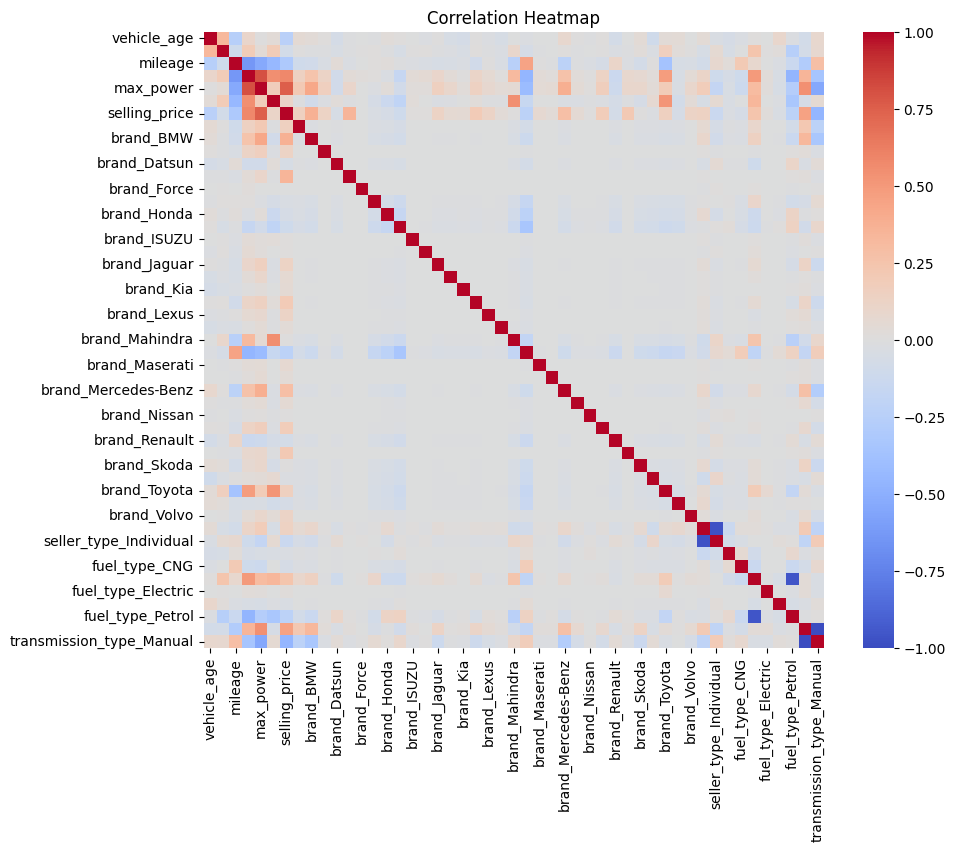

In [ ]:
 plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()